📊 Clusterización de artículos aplicables a forecast

Este notebook desarrolla la segmentación matemática de los artículos que aplican a forecast, utilizando variables construidas a partir del historial de ventas de los últimos 24 meses.

Procedimiento general

1. Importación del dataset preparado
Carga de la base filtrada y enriquecida proveniente del notebook anterior.

2. Validación de variables
Revisión de columnas, tipos de datos, valores nulos, infinitos y consistencia general.

3. Selección de variables de clusterización
Uso de variables finales asociadas a volumen, frecuencia, intermitencia, recencia, variabilidad, picos, tendencia y estacionalidad.

4. Preparación de la matriz de datos
Separación entre columnas de identificación del artículo y variables numéricas para modelado.

5. Escalamiento de variables
Estandarización de los datos para evitar que variables de mayor magnitud dominen el agrupamiento.

6. Evaluación del número óptimo de clusters
Aplicación del método del codo, Silhouette Score y análisis visual.

7. Aplicación de modelos de clusterización
Prueba inicial con K-Means y posible comparación con otros métodos no supervisados.

8. Visualización de resultados
Uso de PCA y gráficos exploratorios para observar la separación de los grupos.

9. Fotografía matemática por cluster
Análisis de promedios, medianas, dispersión y distribución de artículos por grupo.

10. Interpretación de clusters
Asignación de nombres descriptivos según el comportamiento histórico de demanda.

11. Preparación para forecast por grupo
Uso de los clusters como base para comparar modelos predictivos y seleccionar el algoritmo más adecuado por tipo de demanda.

In [92]:
# ============================================================
# 1. Importación de librerías
# ============================================================
# Se importan las librerías necesarias para manipulación de datos,
# visualización, escalamiento, clusterización y evaluación de clusters.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

In [93]:
from datetime import datetime

# ============================================================
# Exportar dataset preparado para clusterización
# ============================================================

fecha_hoy = datetime.today().strftime("%Y_%m_%d")

nombre_archivo = f"df_a_clusterizar_variables_cluster_final_2026_07_24.xlsx"

ruta=f"./Datos/{nombre_archivo}"


In [94]:
# ============================================================
# 2. Carga del dataset preparado para clusterización
# ============================================================
# Este archivo proviene del notebook anterior, donde se filtraron
# los artículos que aplican a forecast y se calcularon las variables
# matemáticas de comportamiento histórico de venta.
# ============================================================

df_cluster = pd.read_excel(ruta)

df_cluster.head()

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,aplica_forecast,motivo_aplica_forecast,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,CENTROS DE CARGA E INTERRUPTORES,NaN,SIEMENS,UNI,True,Aplica forecast,11225.00,67,0.845612,4,0,15.180870,-0.668349,0.495099
1,W8,"Cinta para husos, Habasit, W-8",FAJAS,BANDAS,CORREAS PLANAS DE TRANSMISION,CORREAS PLANAS DE TRANSMISION,HABASIT ROCUA,CM2,True,Aplica forecast,5975816.38,56,0.964050,4,1,-5326.251196,-0.275883,0.989061
2,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",FAJAS,CORREAS,REDONDAS,REDONDAS,SHARDA,MT,True,Aplica forecast,2058.42,47,0.507788,2,1,-0.823330,-0.224816,1.285581
3,C3.5-TEH-14.984,RODILLO RETRO PSV/1.20F14.89N.38,POLEAS RODI.Y TAMB.,NaN,NaN,NaN,PRECISION INC,UNI,True,Aplica forecast,572.00,20,1.349650,6,0,1.013913,-0.137333,0.507343
4,RB330-3PLY-24''-SHRD,"Banda de Hule y lona de 24"" 3 lonas",FAJAS,CORREAS,REDONDAS,REDONDAS,SHARDA,MT,True,Aplica forecast,1393.68,46,1.223552,3,0,0.652261,-0.291110,0.661989


In [95]:
# ============================================================
# 3. Validación inicial del dataset
# ============================================================

print("Dimensiones del dataset:")
print(df_cluster.shape)

print("\nColumnas disponibles:")
print(df_cluster.columns.tolist())

print("\nTipos de datos:")
df_cluster.info()

Dimensiones del dataset:
(450, 18)

Columnas disponibles:
['codigo_articulo', 'descripcion_completa', 'grupo_articulo', 'categoria', 'subcategoria', 'tipo', 'marca_fabricante', 'unidad_medida_inventario', 'aplica_forecast', 'motivo_aplica_forecast', 'total_unidades_vendidas_24m', 'conteo_facturas_24m', 'ratio_venta_reciente_6m', 'cantidad_meses_pico_24m', 'meses_desde_ultima_venta', 'pendiente_tendencia_24m', 'correlacion_estacional_12m', 'cv_meses_con_venta_24m']

Tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   codigo_articulo              450 non-null    str    
 1   descripcion_completa         449 non-null    str    
 2   grupo_articulo               450 non-null    str    
 3   categoria                    411 non-null    str    
 4   subcategoria                 411 non-null    str    
 5   tipo     

In [96]:
# ============================================================
# 3.1 Revisión rápida de valores nulos
# ============================================================

nulos = (
    df_cluster
    .isna()
    .sum()
    .sort_values(ascending=False)
)

nulos[nulos>0]

tipo                    44
categoria               39
subcategoria            39
descripcion_completa     1
dtype: int64

 10  total_unidades_vendidas_24m  450 non-null    float64
 11  conteo_facturas_24m          450 non-null    int64  
 12  ratio_venta_reciente_6m      450 non-null    float64
 13  cantidad_meses_pico_24m      450 non-null    int64  
 14  meses_desde_ultima_venta     450 non-null    int64  
 15  pendiente_tendencia_24m      450 non-null    float64
 16  correlacion_estacional_12m   450 non-null    float64
 17  cv_meses_con_venta_24m

In [97]:
# ============================================================
# 4. Variables finales para clusterización
# ============================================================
# Estas variables fueron seleccionadas después de analizar redundancia
# mediante matriz de correlación y representan diferentes dimensiones
# del comportamiento histórico de venta.
# ============================================================

variables_cluster_final = [
    "total_unidades_vendidas_24m",
    "conteo_facturas_24m",
    "ratio_venta_reciente_6m",
    "cantidad_meses_pico_24m",
    "meses_desde_ultima_venta",
    "pendiente_tendencia_24m",
    "correlacion_estacional_12m",
    "cv_meses_con_venta_24m"
]

In [98]:
# ============================================================
# 4.1 Validar que todas las variables existan en el DataFrame
# ============================================================

variables_faltantes = [
    variable for variable in variables_cluster_final
    if variable not in df_cluster.columns
]

if len(variables_faltantes) == 0:
    print("✅ Todas las variables de clusterización existen en el DataFrame.")
else:
    print("⚠️ Variables faltantes:")
    print(variables_faltantes)

✅ Todas las variables de clusterización existen en el DataFrame.


In [99]:
# ============================================================
# 5. Separar columnas de identificación y variables numéricas
# ============================================================
# Los identificadores se conservan para interpretar los resultados,
# pero no se utilizan como entrada del algoritmo de clusterización.
# ============================================================

columnas_identificacion = [
    "codigo_articulo",
    "descripcion_completa",
    "grupo_articulo",
    "categoria",
    "subcategoria",
    "tipo",
    "marca_fabricante",
    "unidad_medida_inventario", 
    "aplica_forecast", 
    "motivo_aplica_forecast"
]

# Conservar únicamente las columnas de identificación que existan
columnas_identificacion = [
    col for col in columnas_identificacion
    if col in df_cluster.columns
]

df_identificacion = df_cluster[columnas_identificacion].copy()

# Matriz de variables matemáticas para clusterización
X = df_cluster[variables_cluster_final].copy()

X.head()

,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
0,11225.00,67,0.845612,4,0,15.180870,-0.668349,0.495099
1,5975816.38,56,0.964050,4,1,-5326.251196,-0.275883,0.989061
2,2058.42,47,0.507788,2,1,-0.823330,-0.224816,1.285581
3,572.00,20,1.349650,6,0,1.013913,-0.137333,0.507343
4,1393.68,46,1.223552,3,0,0.652261,-0.291110,0.661989


In [100]:
# ============================================================
# 6. Limpieza de matriz numérica
# ============================================================
# Se convierten las variables a formato numérico, se reemplazan
# valores infinitos y se imputan valores nulos con 0.
# ============================================================

X = (
    X
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

X.describe().T

,count,mean,std,min,25%,50%,75%,max
total_unidades_vendidas_24m,450.0,84939.830356,583677.707659,12.000000,30.000000,69.000000,367.500000,6.219703e+06
conteo_facturas_24m,450.0,21.888889,23.823892,6.000000,9.250000,14.000000,24.000000,2.120000e+02
ratio_venta_reciente_6m,450.0,0.840109,0.564918,0.000000,0.425024,0.761905,1.142857,3.100000e+00
cantidad_meses_pico_24m,450.0,3.491111,1.373034,1.000000,3.000000,3.500000,4.000000,1.000000e+01
meses_desde_ultima_venta,450.0,1.800000,2.193329,0.000000,0.000000,1.000000,3.000000,1.300000e+01
pendiente_tendencia_24m,450.0,-28.071955,675.591955,-6622.842487,-0.116848,-0.028696,0.072935,6.461302e+03
correlacion_estacional_12m,450.0,-0.011506,0.303846,-0.668349,-0.241708,-0.082825,0.177860,9.573920e-01
cv_meses_con_venta_24m,450.0,0.742775,0.284956,0.202031,0.571410,0.690622,0.873531,2.475595e+00


## Antes de proceder con el escalado de variables de clusterización, analizaremos su distribución para evaluar si es necesario realizar una transformación previa al escalado. 
esto con el fin de evitar escalar un variable con una tendencia muy sesgada, esto pudiera generar un error metodologico dando lugar a una clusterización sin sentido practico donde k-means=2 (Valores normales Vs Valores atipicos)

Transformación de variables previo a la clusterización

Antes de aplicar algoritmos de clusterización, se revisa la distribución de las variables seleccionadas. Este paso es necesario porque K-Means utiliza distancias entre observaciones, por lo que variables con colas largas, sesgo pronunciado u outliers extremos pueden dominar el agrupamiento.

El objetivo de esta sección es aplicar transformaciones diferenciadas según la naturaleza matemática de cada variable. Para variables positivas con fuerte sesgo hacia la derecha se utilizará transformación logarítmica log1p; para variables con valores negativos o distribuciones con outliers severos se evaluará Yeo-Johnson; y posteriormente se aplicará escalamiento robusto para reducir la influencia de valores extremos.

Este procedimiento busca que la clusterización capture patrones reales de comportamiento histórico de demanda, en lugar de separar únicamente artículos típicos frente a artículos extremos.

In [101]:
# ============================================================
# Análisis de distribución de variables de clusterización
# ============================================================
# Objetivo:
# Revisar la forma de distribución de cada variable antes de decidir
# si conviene aplicar StandardScaler, RobustScaler, transformación logarítmica
# u otro tratamiento previo a la clusterización.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [102]:
# ============================================================
# 1. Preparar matriz base para transformación
# ============================================================
# Se parte de la matriz X original, antes del escalamiento.
# Esta matriz contiene únicamente variables numéricas de comportamiento
# histórico de venta.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler, StandardScaler, PowerTransformer

X_base= X.copy()

X_base = (
    X_base
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

X_base.head()

,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
0,11225.00,67,0.845612,4,0,15.180870,-0.668349,0.495099
1,5975816.38,56,0.964050,4,1,-5326.251196,-0.275883,0.989061
2,2058.42,47,0.507788,2,1,-0.823330,-0.224816,1.285581
3,572.00,20,1.349650,6,0,1.013913,-0.137333,0.507343
4,1393.68,46,1.223552,3,0,0.652261,-0.291110,0.661989


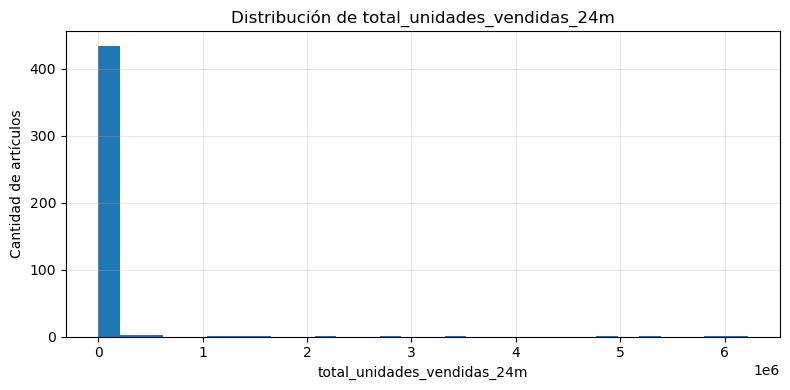

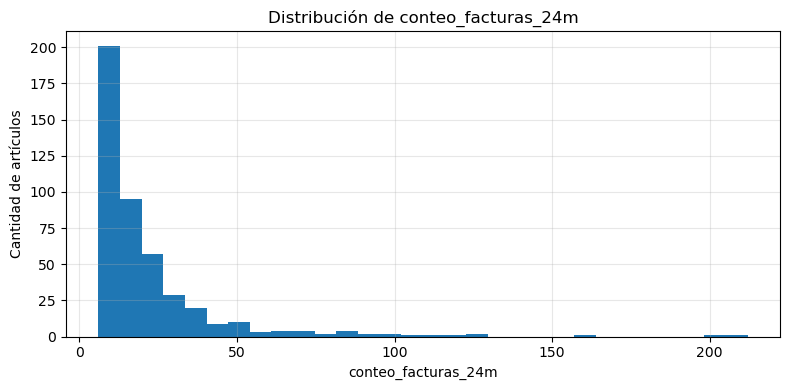

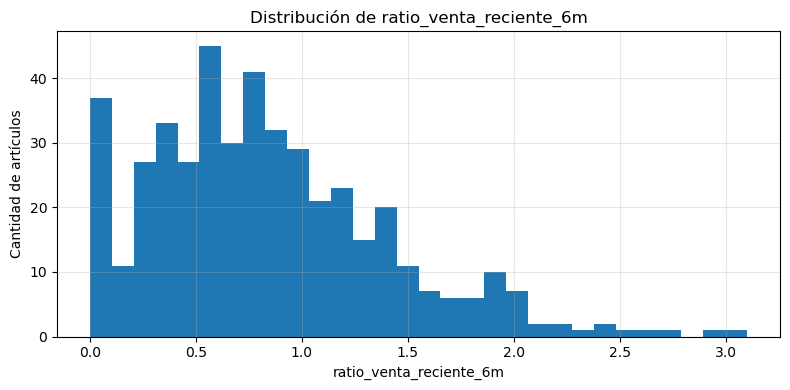

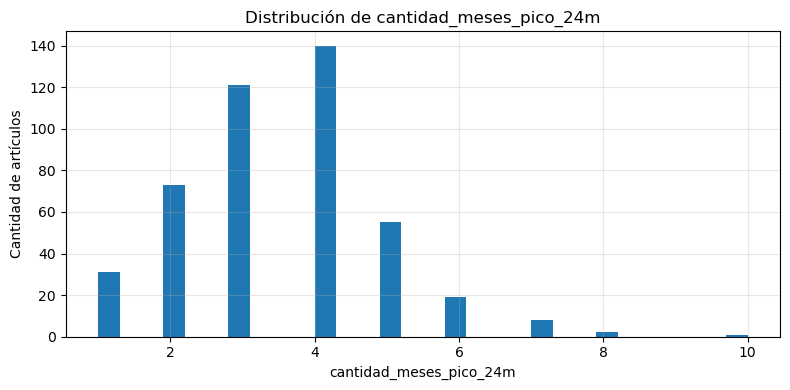

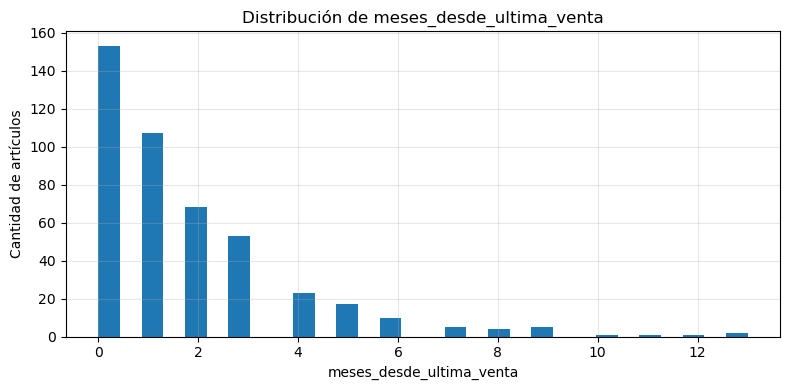

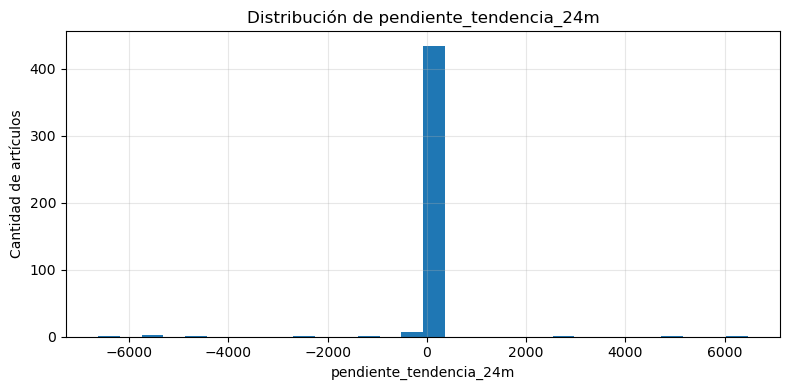

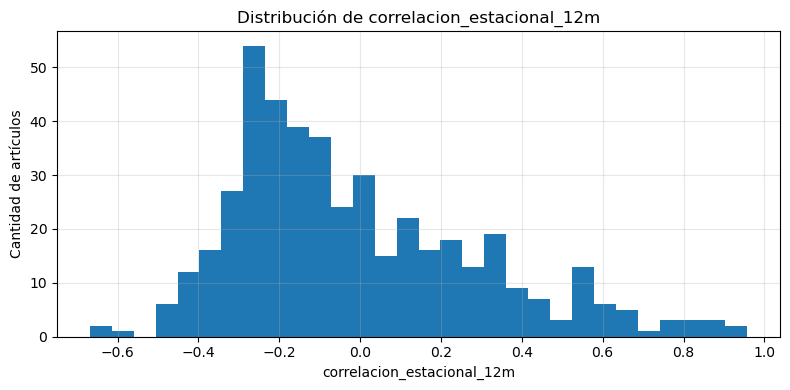

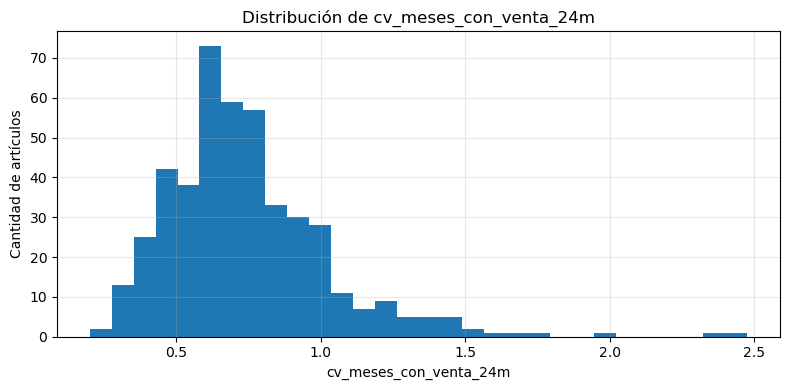

In [103]:
# ============================================================
# 4. Histogramas individuales por variable
# ============================================================
# Permiten observar visualmente si la variable tiene concentración,
# cola larga, muchos ceros o valores extremos.
# ============================================================

for variable in variables_cluster_final:
    plt.figure(figsize=(8, 4))

    plt.hist(
        X_base[variable].dropna(),
        bins=30
    )

    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Cantidad de artículos")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

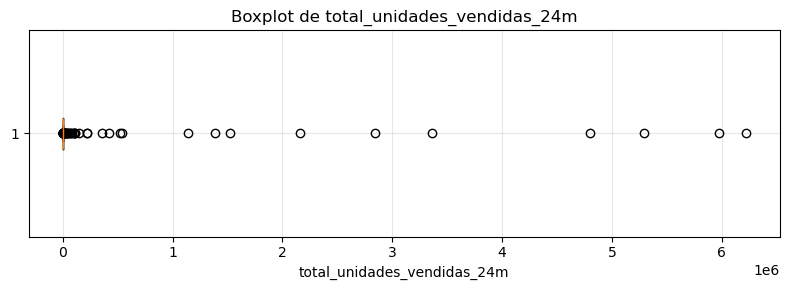

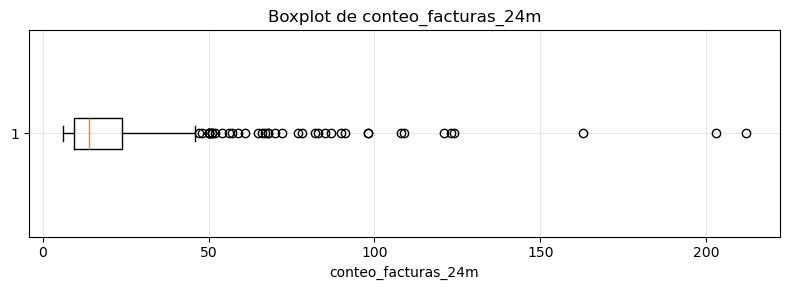

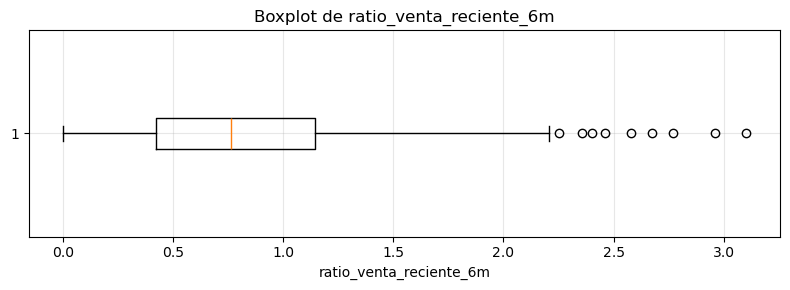

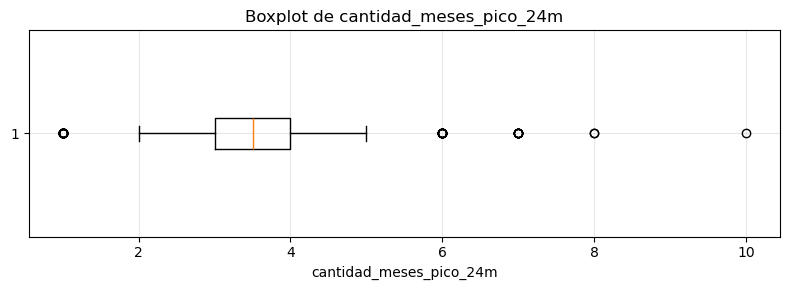

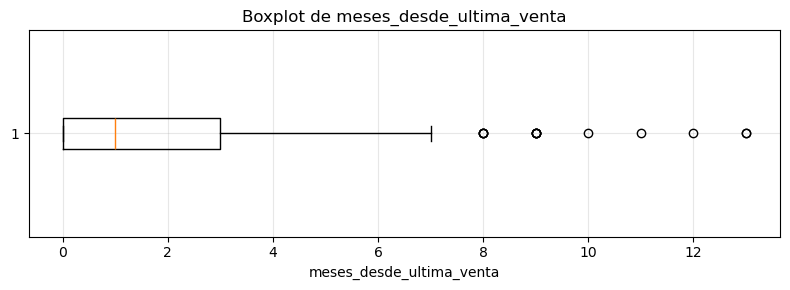

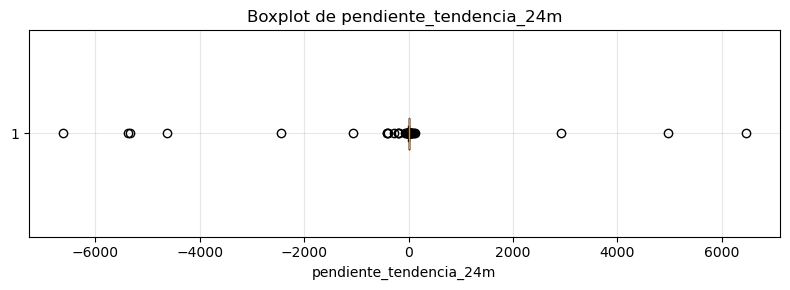

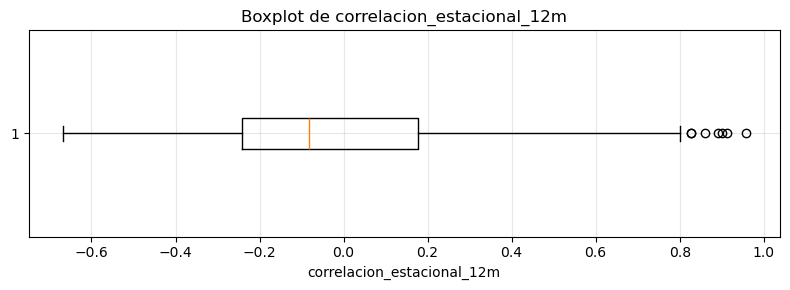

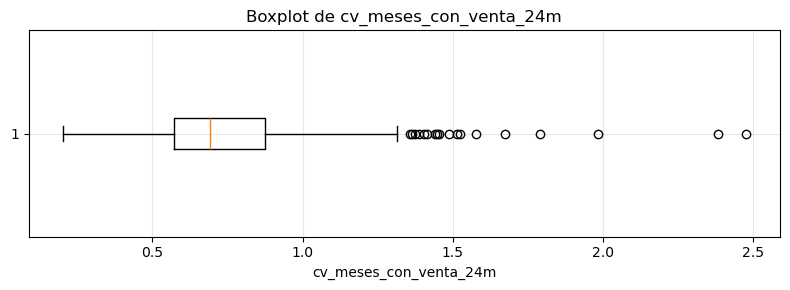

In [104]:
# ============================================================
# 5. Boxplots individuales por variable
# ============================================================
# Ayudan a detectar visualmente valores atípicos.
# ============================================================

for variable in variables_cluster_final:
    plt.figure(figsize=(8, 3))

    plt.boxplot(
        X_base[variable].dropna(),
        vert=False
    )

    plt.title(f"Boxplot de {variable}")
    plt.xlabel(variable)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [105]:
X_base

,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
0,11225.00,67,0.845612,4,0,15.180870,-0.668349,0.495099
1,5975816.38,56,0.964050,4,1,-5326.251196,-0.275883,0.989061
2,2058.42,47,0.507788,2,1,-0.823330,-0.224816,1.285581
3,572.00,20,1.349650,6,0,1.013913,-0.137333,0.507343
4,1393.68,46,1.223552,3,0,0.652261,-0.291110,0.661989
...,...,...,...,...,...,...,...,...
445,19.00,14,1.473684,2,2,0.044783,-0.051917,0.833841
446,15.00,13,0.533333,3,1,-0.060870,0.033389,0.597614
447,303.00,11,1.201320,4,3,0.165652,-0.185261,0.673910
448,17.00,11,1.411765,2,1,0.026522,0.326056,0.725225


In [106]:
# ============================================================
# 2. Estadística descriptiva ampliada
# ============================================================
# Se incluyen percentiles bajos y altos para detectar colas largas,
# concentración de valores y posibles outliers.
# ============================================================

resumen_distribucion = (
   X_base.describe(
        percentiles=[
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
    .T
    .round(2)
)

resumen_distribucion

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
total_unidades_vendidas_24m,450.0,84939.83,583677.71,12.00,12.49,15.00,17.00,30.00,69.00,367.50,2066.67,69246.41,3111238.28,6219703.00
conteo_facturas_24m,450.0,21.89,23.82,6.00,6.00,7.00,7.00,9.25,14.00,24.00,42.10,66.55,122.02,212.00
ratio_venta_reciente_6m,450.0,0.84,0.56,0.00,0.00,0.00,0.19,0.43,0.76,1.14,1.58,1.90,2.52,3.10
cantidad_meses_pico_24m,450.0,3.49,1.37,1.00,1.00,1.00,2.00,3.00,3.50,4.00,5.00,6.00,7.00,10.00
meses_desde_ultima_venta,450.0,1.80,2.19,0.00,0.00,0.00,0.00,0.00,1.00,3.00,5.00,6.00,9.51,13.00
pendiente_tendencia_24m,450.0,-28.07,675.59,-6622.84,-1764.90,-3.00,-0.54,-0.12,-0.03,0.07,0.65,2.63,96.81,6461.30
correlacion_estacional_12m,450.0,-0.01,0.30,-0.67,-0.46,-0.38,-0.32,-0.24,-0.08,0.18,0.43,0.58,0.84,0.96
cv_meses_con_venta_24m,450.0,0.74,0.28,0.20,0.31,0.39,0.44,0.57,0.69,0.87,1.04,1.26,1.63,2.48


In [107]:
# ============================================================
# 2. Función de diagnóstico por variable
# ============================================================
# Calcula métricas necesarias para decidir si una variable requiere:
# - winsorización
# - transformación logarítmica
# - transformación Yeo-Johnson
# - ninguna transformación
# ============================================================

def diagnosticar_variable(serie):
    serie = (
        pd.to_numeric(serie, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    return {
        "media": serie.mean(),
        "mediana": serie.median(),
        "std": serie.std(),
        "min": serie.min(),
        "max": serie.max(),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "skewness": serie.skew(),
        "kurtosis": serie.kurtosis(),
        "p01": serie.quantile(0.01),
        "p05": serie.quantile(0.05),
        "p95": serie.quantile(0.95),
        "p97": serie.quantile(0.97)
    }

In [108]:
# ============================================================
# 2. Diagnóstico de distribución por variable
# ============================================================
# Se calculan métricas de forma para decidir el tratamiento:
#
# - skewness: mide el sesgo de la distribución.
# - kurtosis: mide colas pesadas o presencia de outliers.
# - min: permite detectar valores negativos.
# - ratio_max_p99: indica qué tan extremo es el valor máximo
#   respecto al percentil 99.
# ============================================================

diagnostico_transformacion = pd.DataFrame({
    "media": X_base.mean(),
    "mediana": X_base.median(),
    "std": X_base.std(),
    "min": X_base.min(),
    "max": X_base.max(),
    "skewness": X_base.skew(),
    "kurtosis": X_base.kurtosis(),
    "p01": X_base.quantile(0.01),
    "p95": X_base.quantile(0.95),
    "p99": X_base.quantile(0.97)
})

diagnostico_transformacion["ratio_max_p99"] = (
    diagnostico_transformacion["max"] /
    diagnostico_transformacion["p99"].replace(0, np.nan)
)
diagnostico_transformacion["ratio_min_p01"] = (
    abs(diagnostico_transformacion["min"]) /
    abs(diagnostico_transformacion["p01"].replace(0, np.nan))
)

diagnostico_transformacion = diagnostico_transformacion.round(2)

diagnostico_transformacion.sort_values("skewness", ascending=False)

,media,mediana,std,min,max,skewness,kurtosis,p01,p95,p99,ratio_max_p99,ratio_min_p01
total_unidades_vendidas_24m,84939.83,69.00,583677.71,12.00,6219703.00,8.48,75.82,12.49,69246.41,294042.47,21.15,0.96
conteo_facturas_24m,21.89,14.00,23.82,6.00,212.00,3.92,21.14,6.00,66.55,84.06,2.52,1.00
meses_desde_ultima_venta,1.80,1.00,2.19,0.00,13.00,2.00,5.19,0.00,6.00,7.53,1.73,NaN
cv_meses_con_venta_24m,0.74,0.69,0.28,0.20,2.48,1.71,6.05,0.31,1.26,1.40,1.77,0.65
ratio_venta_reciente_6m,0.84,0.76,0.56,0.00,3.10,0.88,0.95,0.00,1.90,2.04,1.52,NaN
correlacion_estacional_12m,-0.01,-0.08,0.30,-0.67,0.96,0.87,0.32,-0.46,0.58,0.67,1.43,1.45
cantidad_meses_pico_24m,3.49,3.50,1.37,1.00,10.00,0.50,1.07,1.00,6.00,6.00,1.67,1.00
pendiente_tendencia_24m,-28.07,-0.03,675.59,-6622.84,6461.30,-2.00,66.85,-1764.90,2.63,20.16,320.47,3.75


In [109]:
# ============================================================
# 3. Función para decidir winsorización
# ============================================================
# La winsorización se aplica cuando existe evidencia de colas extremas.
#
# Criterios:
# - kurtosis >= 10: colas pesadas / outliers severos.
# - abs(skewness) >= 2 y kurtosis >= 5: sesgo fuerte con colas relevantes.
#
# Se aplica antes de otras transformaciones para reducir la influencia
# de valores extremos sobre el proceso posterior.
# ============================================================

def debe_winsorizar(
    serie,
    umbral_kurtosis_extrema=5,
    umbral_skew_extremo=2,

):
    diagnostico = diagnosticar_variable(serie)

    skewness = diagnostico["skewness"]
    kurtosis = diagnostico["kurtosis"]
    iqr = diagnostico["iqr"]

    # Si el IQR es cero, la variable no tiene dispersión central suficiente
    # para construir límites robustos por IQR.
    if iqr == 0 or np.isnan(iqr):
        return False
    
    if kurtosis >= umbral_kurtosis_extrema:
        return True

    if abs(skewness) >= umbral_skew_extremo:
        return True

    return False

In [110]:
def aplicar_winsorizacion_iqr(serie, factor_iqr=2.0):    
    """
    Aplica winsorización basada en límites robustos por IQR.
    """

    diagnostico = diagnosticar_variable(serie)

    q1 = diagnostico["q1"]
    q3 = diagnostico["q3"]
    iqr = diagnostico["iqr"]

    limite_inferior = q1 - factor_iqr * iqr
    limite_superior = q3 + factor_iqr * iqr

    serie_winsorizada = serie.clip(
        lower=limite_inferior,
        upper=limite_superior
    )

    return serie_winsorizada, limite_inferior, limite_superior

In [111]:
serie_w=aplicar_winsorizacion_iqr(X_base["total_unidades_vendidas_24m"])[0]
serie_w.describe()


count     450.000000
mean      276.367733
std       372.296332
min        12.000000
25%        30.000000
50%        69.000000
75%       367.500000
max      1042.500000
Name: total_unidades_vendidas_24m, dtype: float64

In [112]:
# ============================================================
# 3. Función para sugerir transformación por variable
# ============================================================
# Reglas utilizadas:
#Skewness = hacia dónde se estira la distribución.
#Kurtosis = qué tan pesadas o extremas son sus colas.Kurtosis me dice si hay valores extremos que pueden dominar las distancias del clustering.
#

# 1. Si la variable tiene valores negativos:
#    - No se puede aplicar log1p directamente.
#    - Si tiene alto sesgo o alta curtosis, se sugiere Yeo-Johnson.
#
# 2. Si la variable es no negativa y tiene skewness alto:
#    - Se sugiere log1p para comprimir la cola derecha.
#
# 3. Si la variable tiene sesgo moderado:
#    - Se puede usar Yeo-Johnson o dejar sin transformación fuerte.
#
# 4. Si la variable tiene rango natural limitado, como correlaciones:
#    - Se conserva sin transformación.
# ============================================================
def sugerir_transformacion_variable(
    serie,
    umbral_skew=1.0,
    umbral_kurtosis=5
):
    """
    Sugiere una transformación según:
    - presencia de valores negativos
    - skewness
    - kurtosis
    - naturaleza de la variable
    """

    serie = (
        pd.to_numeric(serie, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    skewness = serie.skew()
    kurtosis = serie.kurtosis()
    minimo = serie.min()

    # Variables con valores negativos
    if minimo < 0:
        if abs(skewness) >= umbral_skew or kurtosis >= umbral_kurtosis:
            return "yeo_johnson"
        else:
            return "sin_transformacion"

    # Variables no negativas con sesgo positivo o colas pesadas
    if minimo >= 0:
        if skewness >= umbral_skew or kurtosis >= umbral_kurtosis:
            return "log1p"
        return "sin_transformacion"

    return "sin_transformacion"

In [113]:
# ============================================================
# 6. Pipeline robusto orientado a comportamiento normal
# ============================================================

X_base = X.copy()

X_base = (
    X_base
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

X_preprocesada = X_base.copy()

registro_preprocesamiento = []
transformadores_yeo_johnson = {}

for variable in X_base.columns:

    diagnostico_original = diagnosticar_variable(X_base[variable])

    aplicar_winsor = debe_winsorizar(
        serie=X_base[variable],
    )

    serie_tratada = X_base[variable].copy()

    if aplicar_winsor:
        serie_tratada, limite_inferior, limite_superior = aplicar_winsorizacion_iqr(
            serie=serie_tratada
        )
    else:
        limite_inferior = np.nan
        limite_superior = np.nan

    diagnostico_post_winsor = diagnosticar_variable(serie_tratada)

    transformacion = sugerir_transformacion_variable(
        serie=serie_tratada
    )

    if transformacion == "log1p":
        serie_transformada = np.log1p(serie_tratada)

    elif transformacion == "yeo_johnson":
        pt = PowerTransformer(
            method="yeo-johnson",
            standardize=False
        )

        serie_transformada = pt.fit_transform(
            serie_tratada.values.reshape(-1, 1)
        ).ravel()

        transformadores_yeo_johnson[variable] = pt

    else:
        serie_transformada = serie_tratada

    X_preprocesada[variable] = serie_transformada

    diagnostico_final = diagnosticar_variable(X_preprocesada[variable])

    registro_preprocesamiento.append({
        "variable": variable,

        "skewness_antes": diagnostico_original["skewness"],
        "kurtosis_antes": diagnostico_original["kurtosis"],
        "min_antes": diagnostico_original["min"],
        "max_antes": diagnostico_original["max"],

        "winsorizado": aplicar_winsor,
        "limite_inferior_winsor": limite_inferior,
        "limite_superior_winsor": limite_superior,

        "skewness_post_winsor": diagnostico_post_winsor["skewness"],
        "kurtosis_post_winsor": diagnostico_post_winsor["kurtosis"],

        "transformacion_aplicada": transformacion,

        "skewness_despues": diagnostico_final["skewness"],
        "kurtosis_despues": diagnostico_final["kurtosis"],
        "min_despues": diagnostico_final["min"],
        "max_despues": diagnostico_final["max"]
    })

df_registro_preprocesamiento = pd.DataFrame(registro_preprocesamiento).round(2)

df_registro_preprocesamiento.sort_values(by="skewness_antes", ascending=False)


,variable,skewness_antes,kurtosis_antes,min_antes,max_antes,winsorizado,limite_inferior_winsor,limite_superior_winsor,skewness_post_winsor,kurtosis_post_winsor,transformacion_aplicada,skewness_despues,kurtosis_despues,min_despues,max_despues
0,total_unidades_vendidas_24m,8.48,75.82,12.00,6219703.00,True,-645.00,1042.50,1.32,0.08,log1p,0.41,-1.21,2.56,6.95
1,conteo_facturas_24m,3.92,21.14,6.00,212.00,True,-20.25,53.50,1.36,0.81,log1p,0.55,-0.74,1.95,4.00
4,meses_desde_ultima_venta,2.00,5.19,0.00,13.00,True,-6.00,9.00,1.59,2.51,log1p,0.32,-0.94,0.00,2.30
7,cv_meses_con_venta_24m,1.71,6.05,0.20,2.48,True,-0.03,1.48,0.84,0.69,sin_transformacion,0.84,0.69,0.20,1.48
2,ratio_venta_reciente_6m,0.88,0.95,0.00,3.10,False,NaN,NaN,0.88,0.95,sin_transformacion,0.88,0.95,0.00,3.10
6,correlacion_estacional_12m,0.87,0.32,-0.67,0.96,False,NaN,NaN,0.87,0.32,sin_transformacion,0.87,0.32,-0.67,0.96
3,cantidad_meses_pico_24m,0.50,1.07,1.00,10.00,False,NaN,NaN,0.50,1.07,sin_transformacion,0.50,1.07,1.00,10.00
5,pendiente_tendencia_24m,-2.00,66.85,-6622.84,6461.30,True,-0.50,0.45,0.05,-0.05,sin_transformacion,0.05,-0.05,-0.50,0.45


In [114]:
X_preprocesada.describe().T

,count,mean,std,min,25%,50%,75%,max
total_unidades_vendidas_24m,450.0,4.636397,1.440284,2.564949,3.433987,4.248495,5.909371,6.950336
conteo_facturas_24m,450.0,2.820451,0.590694,1.945910,2.326413,2.708050,3.218876,3.998201
ratio_venta_reciente_6m,450.0,0.840109,0.564918,0.000000,0.425024,0.761905,1.142857,3.100000
cantidad_meses_pico_24m,450.0,3.491111,1.373034,1.000000,3.000000,3.500000,4.000000,10.000000
meses_desde_ultima_venta,450.0,0.781098,0.678587,0.000000,0.000000,0.693147,1.386294,2.302585
pendiente_tendencia_24m,450.0,-0.024109,0.256886,-0.496413,-0.116848,-0.028696,0.072935,0.452500
correlacion_estacional_12m,450.0,-0.011506,0.303846,-0.668349,-0.241708,-0.082825,0.177860,0.957392
cv_meses_con_venta_24m,450.0,0.735855,0.256913,0.202031,0.571410,0.690622,0.873531,1.477771


In [115]:
# ============================================================
# Escalamiento robusto posterior al preprocesamiento
# ============================================================

from sklearn.preprocessing import RobustScaler

scaler_robust = RobustScaler()

X_scaled= pd.DataFrame(
    scaler_robust.fit_transform(X_preprocesada),
    columns=X_preprocesada.columns,
    index=X_preprocesada.index
)

X_scaled.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
total_unidades_vendidas_24m,450.0,0.16,0.58,-0.68,-0.33,0.0,0.67,1.09
conteo_facturas_24m,450.0,0.13,0.66,-0.85,-0.43,0.0,0.57,1.45
ratio_venta_reciente_6m,450.0,0.11,0.79,-1.06,-0.47,0.0,0.53,3.26
cantidad_meses_pico_24m,450.0,-0.01,1.37,-2.50,-0.50,0.0,0.50,6.50
meses_desde_ultima_venta,450.0,0.06,0.49,-0.50,-0.50,0.0,0.50,1.16
pendiente_tendencia_24m,450.0,0.02,1.35,-2.46,-0.46,0.0,0.54,2.54
correlacion_estacional_12m,450.0,0.17,0.72,-1.40,-0.38,0.0,0.62,2.48
cv_meses_con_venta_24m,450.0,0.15,0.85,-1.62,-0.39,0.0,0.61,2.61


In [116]:
diagnostico_scaled = X_scaled.describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

diagnostico_scaled["rango_scaled"] = (
    diagnostico_scaled["max"] - diagnostico_scaled["min"]
).round(2)

diagnostico_scaled["posible_dominancia"] = np.where(
    (diagnostico_scaled["std"] > 3) |
    (diagnostico_scaled["max"].abs() > 8) |
    (diagnostico_scaled["min"].abs() > 8),
    "Revisar",
    "OK"
)

diagnostico_scaled.sort_values("rango_scaled", ascending=False)

,mean,std,min,25%,50%,75%,max,rango_scaled,posible_dominancia
cantidad_meses_pico_24m,-0.01,1.37,-2.50,-0.50,0.0,0.50,6.50,9.00,OK
pendiente_tendencia_24m,0.02,1.35,-2.46,-0.46,0.0,0.54,2.54,5.00,OK
ratio_venta_reciente_6m,0.11,0.79,-1.06,-0.47,0.0,0.53,3.26,4.32,OK
cv_meses_con_venta_24m,0.15,0.85,-1.62,-0.39,0.0,0.61,2.61,4.23,OK
correlacion_estacional_12m,0.17,0.72,-1.40,-0.38,0.0,0.62,2.48,3.88,OK
conteo_facturas_24m,0.13,0.66,-0.85,-0.43,0.0,0.57,1.45,2.30,OK
total_unidades_vendidas_24m,0.16,0.58,-0.68,-0.33,0.0,0.67,1.09,1.77,OK
meses_desde_ultima_venta,0.06,0.49,-0.50,-0.50,0.0,0.50,1.16,1.66,OK


In [117]:
# ============================================================
# 9. Evaluación del número óptimo de clusters
# ============================================================
# En esta sección se prueban distintos valores de k para K-Means.
#
# Métricas evaluadas:
# - Inertia: compactación interna de los clusters. Menor es mejor.
# - Silhouette Score: separación y cohesión de clusters. Mayor es mejor.
# - Davies-Bouldin Index: similitud entre clusters. Menor es mejor.
# - Calinski-Harabasz Score: separación entre clusters. Mayor es mejor.
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

resultados_k = []

rango_k = range(2, 10)

for k in rango_k:
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = modelo_kmeans.fit_predict(X_scaled)
    
    inertia = modelo_kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    
    resultados_k.append({
        "k": k,
        "inertia": inertia,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
        "calinski_harabasz_score": calinski_harabasz
    })

df_resultados_k = pd.DataFrame(resultados_k)

df_resultados_k

c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\tesis_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\tesis_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\tesis_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\CHOPPE\Documents\CE

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,2321.701900,0.194834,1.773450,123.868172
1,3,1852.326032,0.223111,1.449421,134.089260
2,4,1572.979938,0.234588,1.322721,131.434417
3,5,1422.760138,0.206407,1.408754,120.485570
4,6,1340.178119,0.190380,1.468143,107.569852
5,7,1264.207005,0.192295,1.464196,99.251356
6,8,1182.697833,0.176151,1.528928,95.082031
7,9,1134.423306,0.172782,1.528409,88.886718


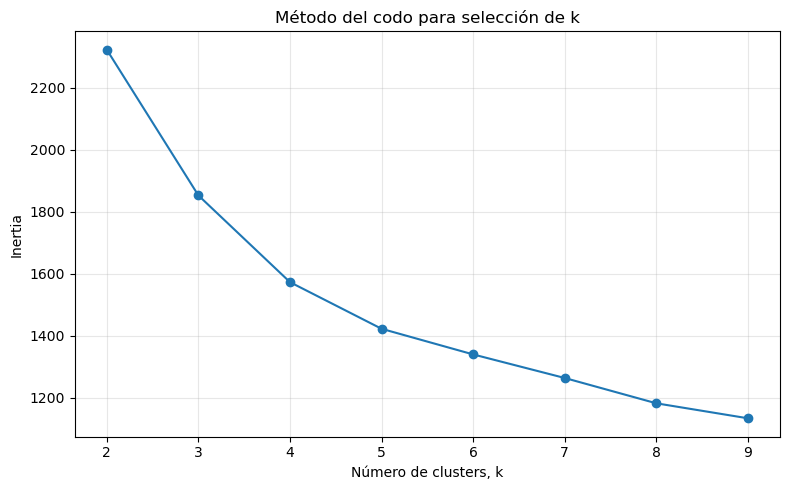

In [118]:
# ============================================================
# 10. Método del codo
# ============================================================
# La inertia mide la suma de distancias internas dentro de cada cluster.
# A mayor número de clusters, la inertia siempre baja.
#
# El objetivo es identificar el punto donde agregar más clusters
# ya no mejora significativamente la compactación.
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_k["k"],
    df_resultados_k["inertia"],
    marker="o"
)

plt.title("Método del codo para selección de k")
plt.xlabel("Número de clusters, k")
plt.ylabel("Inertia")
plt.xticks(list(rango_k))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

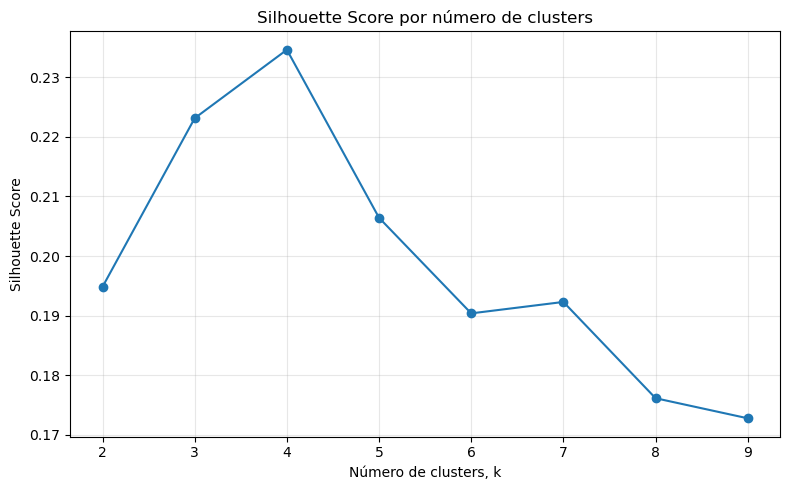

In [119]:
# ============================================================
# 11. Silhouette Score por número de clusters
# ============================================================
# El Silhouette Score mide qué tan bien separado está cada punto
# respecto a su propio cluster y a los clusters vecinos.
#
# Valores más altos indican mejor separación.
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_k["k"],
    df_resultados_k["silhouette_score"],
    marker="o"
)

plt.title("Silhouette Score por número de clusters")
plt.xlabel("Número de clusters, k")
plt.ylabel("Silhouette Score")
plt.xticks(list(rango_k))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

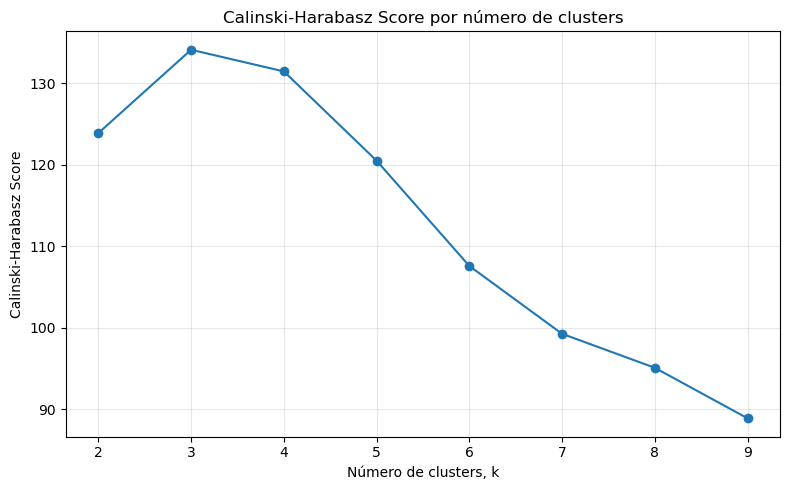

In [120]:
# ============================================================
# 13. Calinski-Harabasz Score por número de clusters
# ============================================================
# Esta métrica compara la separación entre clusters contra
# la dispersión interna de cada cluster.
#
# Valores más altos indican mejor estructura de agrupamiento.
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_k["k"],
    df_resultados_k["calinski_harabasz_score"],
    marker="o"
)

plt.title("Calinski-Harabasz Score por número de clusters")
plt.xlabel("Número de clusters, k")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(list(rango_k))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [121]:
# ============================================================
# 14. Tabla comparativa de métricas por k
# ============================================================

df_resultados_k.sort_values(
    by="silhouette_score",
    ascending=False
).head(10)

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
2,4,1572.979938,0.234588,1.322721,131.434417
1,3,1852.326032,0.223111,1.449421,134.089260
3,5,1422.760138,0.206407,1.408754,120.485570
0,2,2321.701900,0.194834,1.773450,123.868172
5,7,1264.207005,0.192295,1.464196,99.251356
4,6,1340.178119,0.190380,1.468143,107.569852
6,8,1182.697833,0.176151,1.528928,95.082031
7,9,1134.423306,0.172782,1.528409,88.886718


In [122]:
# ============================================================
# Comparación práctica de soluciones candidatas
# ============================================================

from sklearn.cluster import KMeans

k_candidatos = [3, 4, 5]

for k in k_candidatos:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    df_cluster[f"cluster_kmeans_{k}"] = modelo.fit_predict(X_scaled)

    print("\n" + "=" * 80)
    print(f"DISTRIBUCIÓN DE ARTÍCULOS PARA k = {k}")
    print("=" * 80)

    distribucion = (
        df_cluster[f"cluster_kmeans_{k}"]
        .value_counts()
        .sort_index()
        .reset_index()
    )

    distribucion.columns = ["cluster", "cantidad_articulos"]

    distribucion["porcentaje"] = (
        distribucion["cantidad_articulos"] /
        distribucion["cantidad_articulos"].sum() * 100
    ).round(2)

    display(distribucion)


DISTRIBUCIÓN DE ARTÍCULOS PARA k = 3


c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\tesis_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,cluster,cantidad_articulos,porcentaje
0,0,190,42.22
1,1,178,39.56
2,2,82,18.22



DISTRIBUCIÓN DE ARTÍCULOS PARA k = 4


c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\tesis_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,cluster,cantidad_articulos,porcentaje
0,0,166,36.89
1,1,61,13.56
2,2,74,16.44
3,3,149,33.11



DISTRIBUCIÓN DE ARTÍCULOS PARA k = 5


c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\tesis_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,cluster,cantidad_articulos,porcentaje
0,0,164,36.44
1,1,68,15.11
2,2,90,20.00
3,3,71,15.78
4,4,57,12.67


In [123]:
# ============================================================
# Perfil promedio por cluster para interpretación rápida
# ============================================================

for k in k_candidatos:
    print("\n" + "=" * 100)
    print(f"PERFIL PROMEDIO DE CLUSTERS PARA k = {k}")
    print("=" * 100)

    perfil = (
        df_cluster
        .groupby(f"cluster_kmeans_{k}")[variables_cluster_final]
        .mean()
        .round(2)
    )

    display(perfil)


PERFIL PROMEDIO DE CLUSTERS PARA k = 3


,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
cluster_kmeans_3,,,,,,,,
0,77876.41,19.02,0.81,4.60,1.83,-55.91,0.01,0.59
1,90570.98,19.79,0.66,2.32,2.25,-96.25,-0.02,0.88
2,89082.57,33.11,1.32,3.46,0.76,184.43,-0.05,0.81



PERFIL PROMEDIO DE CLUSTERS PARA k = 4


,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
cluster_kmeans_4,,,,,,,,
0,3364.50,17.21,0.82,4.70,1.91,-1.12,0.02,0.57
1,497529.94,35.79,0.59,2.89,1.72,-451.88,-0.01,0.94
2,98701.62,35.35,1.31,3.53,0.69,204.35,-0.03,0.80
3,74.97,14.72,0.73,2.37,2.26,-0.02,-0.03,0.82



PERFIL PROMEDIO DE CLUSTERS PARA k = 5


,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
cluster_kmeans_5,,,,,,,,
0,98.09,16.23,0.79,3.57,1.90,-0.02,-0.02,0.65
1,8045.30,16.79,0.90,5.63,1.79,-2.64,0.04,0.51
2,1770.53,17.12,0.66,1.74,2.52,-11.91,0.01,1.01
3,102822.68,35.56,1.33,3.51,0.66,212.98,-0.03,0.81
4,529824.53,34.75,0.58,3.46,1.81,-464.91,-0.08,0.79


In [124]:
df_cluster

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,aplica_forecast,motivo_aplica_forecast,...,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m,cluster_kmeans_3,cluster_kmeans_4,cluster_kmeans_5
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,CENTROS DE CARGA E INTERRUPTORES,NaN,SIEMENS,UNI,True,Aplica forecast,...,67,0.845612,4,0,15.180870,-0.668349,0.495099,2,2,3
1,W8,"Cinta para husos, Habasit, W-8",FAJAS,BANDAS,CORREAS PLANAS DE TRANSMISION,CORREAS PLANAS DE TRANSMISION,HABASIT ROCUA,CM2,True,Aplica forecast,...,56,0.964050,4,1,-5326.251196,-0.275883,0.989061,0,1,4
2,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",FAJAS,CORREAS,REDONDAS,REDONDAS,SHARDA,MT,True,Aplica forecast,...,47,0.507788,2,1,-0.823330,-0.224816,1.285581,1,1,4
3,C3.5-TEH-14.984,RODILLO RETRO PSV/1.20F14.89N.38,POLEAS RODI.Y TAMB.,NaN,NaN,NaN,PRECISION INC,UNI,True,Aplica forecast,...,20,1.349650,6,0,1.013913,-0.137333,0.507343,2,2,3
4,RB330-3PLY-24''-SHRD,"Banda de Hule y lona de 24"" 3 lonas",FAJAS,CORREAS,REDONDAS,REDONDAS,SHARDA,MT,True,Aplica forecast,...,46,1.223552,3,0,0.652261,-0.291110,0.661989,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,3L220,"Correa trapezoidal estandar, 3L220, Longitud e...",FAJAS,CORREAS,TRAPEZOIDALES,ESTANDAR,BANDO,UNI,True,Aplica forecast,...,14,1.473684,2,2,0.044783,-0.051917,0.833841,1,3,2
446,A028,"Correa trapezoidal estandar, A28, Longitud ext...",FAJAS,CORREAS,TRAPEZOIDALES,ESTANDAR,BANDO,UNI,True,Aplica forecast,...,13,0.533333,3,1,-0.060870,0.033389,0.597614,1,3,0
447,150XL,"Manga de sincronismo, 150XL, longitud externa ...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,True,Aplica forecast,...,11,1.201320,4,3,0.165652,-0.185261,0.673910,2,0,0
448,3L250,Faja trapezoidal,FAJAS,NaN,NaN,NaN,BANDO,UNI,True,Aplica forecast,...,11,1.411765,2,1,0.026522,0.326056,0.725225,1,3,2


In [125]:
# ============================================================
# 1. Entrenamiento final de K-Means con k = 4
# ============================================================
# Se utiliza la matriz X_scaled_final, que ya contiene:
# - winsorizado robusto
# - transformaciones según distribución
# - escalamiento robusto
# ============================================================

from sklearn.cluster import KMeans

k_final = 4

modelo_kmeans_final = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

df_cluster["cluster_kmeans_final"] = modelo_kmeans_final.fit_predict(X_scaled)

round(df_cluster["cluster_kmeans_final"].value_counts(normalize=True)*100,1)

c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\tesis_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


cluster_kmeans_final
0    36.9
3    33.1
2    16.4
1    13.6
Name: proportion, dtype: float64

In [126]:
# ============================================================
# 2. Distribución de artículos por cluster
# ============================================================

distribucion_clusters = (
    df_cluster["cluster_kmeans_final"]
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_clusters.columns = ["cluster", "cantidad_articulos"]

distribucion_clusters["porcentaje"] = (
    distribucion_clusters["cantidad_articulos"] /
    distribucion_clusters["cantidad_articulos"].sum() * 100
).round(2)

distribucion_clusters

,cluster,cantidad_articulos,porcentaje
0,0,166,36.89
1,1,61,13.56
2,2,74,16.44
3,3,149,33.11


In [127]:
# ============================================================
# 3. Perfil promedio por cluster con variables originales
# ============================================================
# Este perfil ayuda a interpretar los clusters en unidades reales.
# ============================================================

perfil_media_original=(df_cluster
                               .groupby("cluster_kmeans_final")[variables_cluster_final]
                               .mean()
                               .round(2))
perfil_media_original

,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
cluster_kmeans_final,,,,,,,,
0,3364.50,17.21,0.82,4.70,1.91,-1.12,0.02,0.57
1,497529.94,35.79,0.59,2.89,1.72,-451.88,-0.01,0.94
2,98701.62,35.35,1.31,3.53,0.69,204.35,-0.03,0.80
3,74.97,14.72,0.73,2.37,2.26,-0.02,-0.03,0.82


In [128]:
# ============================================================
# 4. Perfil mediano por cluster con variables originales
# ============================================================

Perfil_mediana_original=(df_cluster
                         .groupby("cluster_kmeans_final")[variables_cluster_final]
                         .median()
                         .round(2))
Perfil_mediana_original

,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
cluster_kmeans_final,,,,,,,,
0,45.5,13.0,0.77,4.0,1.0,-0.03,-0.04,0.58
1,912.0,24.0,0.55,3.0,1.0,-1.34,-0.14,0.87
2,891.5,23.5,1.22,3.5,0.0,1.07,-0.10,0.75
3,37.0,11.0,0.59,3.0,2.0,-0.02,-0.11,0.78


In [129]:
# ============================================================
# 5. Fotografía matemática completa por cluster
# ============================================================
# Esta tabla muestra count, mean, median, std, min y max por variable.
# Sirve para entender la dispersión interna de cada grupo.
# ============================================================

fotografia_clusters= (df_cluster.groupby("cluster_kmeans_final")[variables_cluster_final]
                                                                 .agg(["count", "mean", "median", "std", "min", "max"]).round(2))
display(fotografia_clusters)


total_unidades_vendidas_24m                    \
                                           count       mean median   
cluster_kmeans_final                                                 
0                                            166    3364.50   45.5   
1                                             61  497529.94  912.0   
2                                             74   98701.62  891.5   
3                                            149      74.97   37.0   

                                                   conteo_facturas_24m         \
                             std   min         max               count   mean   
cluster_kmeans_final                                                            
0                       41823.02  13.0   538962.10                 166  17.21   
1                     1460944.86  60.0  6219703.00                  61  35.79   
2                      406102.81  31.0  2846006.99                  74  35.35   
3                         144.38  12.0     1066.00                 149  14.72   

                                    ... correlacion_estacional_12m        \
                     median    std  ...                     median   std   
cluster_kmeans_final                ...                                    
0                      13.0  13.93  ...                      -0.04  0.30   
1                      24.0  33.95  ...                      -0.14  0.34   
2                      23.5  36.10  ...                      -0.10  0.31   
3                      11.0  12.20  ...                      -0.11  0.29   

                                 cv_meses_con_venta_24m                     \
                       min   max                  count  mean median   std   
cluster_kmeans_final                                                         
0                    -0.61  0.96                    166  0.57   0.58  0.16   
1                    -0.46  0.91                     61  0.94   0.87  0.34   
2                    -0.67  0.89                     74  0.80   0.75  0.27   
3                    -0.64  0.90                    149  0.82   0.78  0.28   

                                  
                       min   max  
cluster_kmeans_final              
0                     0.20  1.21  
1                     0.41  2.38  
2                     0.30  1.98  
3                     0.32  2.48  

[4 rows x 48 columns]

In [130]:
# ============================================================
# 5. Fotografía matemática completa por cluster
# ============================================================
# Esta tabla muestra count, mean, median, std, min y max por variable.
# Sirve para entender la dispersión interna de cada grupo.
# ============================================================

fotografia_clusters = (
    df_cluster
    .groupby("cluster_kmeans_final")[variables_cluster_final]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

fotografia_clusters

total_unidades_vendidas_24m                    \
                                           count       mean median   
cluster_kmeans_final                                                 
0                                            166    3364.50   45.5   
1                                             61  497529.94  912.0   
2                                             74   98701.62  891.5   
3                                            149      74.97   37.0   

                                                   conteo_facturas_24m         \
                             std   min         max               count   mean   
cluster_kmeans_final                                                            
0                       41823.02  13.0   538962.10                 166  17.21   
1                     1460944.86  60.0  6219703.00                  61  35.79   
2                      406102.81  31.0  2846006.99                  74  35.35   
3                         144.38  12.0     1066.00                 149  14.72   

                                    ... correlacion_estacional_12m        \
                     median    std  ...                     median   std   
cluster_kmeans_final                ...                                    
0                      13.0  13.93  ...                      -0.04  0.30   
1                      24.0  33.95  ...                      -0.14  0.34   
2                      23.5  36.10  ...                      -0.10  0.31   
3                      11.0  12.20  ...                      -0.11  0.29   

                                 cv_meses_con_venta_24m                     \
                       min   max                  count  mean median   std   
cluster_kmeans_final                                                         
0                    -0.61  0.96                    166  0.57   0.58  0.16   
1                    -0.46  0.91                     61  0.94   0.87  0.34   
2                    -0.67  0.89                     74  0.80   0.75  0.27   
3                    -0.64  0.90                    149  0.82   0.78  0.28   

                                  
                       min   max  
cluster_kmeans_final              
0                     0.20  1.21  
1                     0.41  2.38  
2                     0.30  1.98  
3                     0.32  2.48  

[4 rows x 48 columns]

In [131]:
# ============================================================
# 6. Perfil relativo del cluster contra el promedio global
# ============================================================
# Se calcula cuántas desviaciones estándar se aleja cada cluster
# del comportamiento promedio general.
# ============================================================

media_global = df_cluster[variables_cluster_final].mean()
std_global = df_cluster[variables_cluster_final].std().replace(0, np.nan)

perfil_relativo_clusters = (
    perfil_media_original - media_global
) / std_global

perfil_relativo_clusters = perfil_relativo_clusters.round(2)

perfil_relativo_clusters

,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
cluster_kmeans_final,,,,,,,,
0,-0.14,-0.20,-0.04,0.88,0.05,0.04,0.10,-0.61
1,0.71,0.58,-0.44,-0.44,-0.04,-0.63,0.00,0.69
2,0.02,0.57,0.83,0.03,-0.51,0.34,-0.06,0.20
3,-0.15,-0.30,-0.19,-0.82,0.21,0.04,-0.06,0.27


In [132]:
# ============================================================
# 7. Variables más distintivas por cluster
# ============================================================
# Se identifican las variables con mayor desviación absoluta
# respecto al promedio global.
# ============================================================

top_variables_por_cluster = []

for cluster in perfil_relativo_clusters.index:
    serie_cluster = perfil_relativo_clusters.loc[cluster]

    variables_mas_altas = (
        serie_cluster
        .abs()
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )

    for variable in variables_mas_altas:
        top_variables_por_cluster.append({
            "cluster": cluster,
            "variable": variable,
            "desviacion_relativa": serie_cluster[variable]
        })

df_top_variables_cluster = pd.DataFrame(top_variables_por_cluster)

df_top_variables_cluster

,cluster,variable,desviacion_relativa
0,0,cantidad_meses_pico_24m,0.88
1,0,cv_meses_con_venta_24m,-0.61
2,0,conteo_facturas_24m,-0.20
3,0,total_unidades_vendidas_24m,-0.14
4,0,correlacion_estacional_12m,0.10
5,1,total_unidades_vendidas_24m,0.71
6,1,cv_meses_con_venta_24m,0.69
7,1,pendiente_tendencia_24m,-0.63
8,1,conteo_facturas_24m,0.58
9,1,cantidad_meses_pico_24m,-0.44


In [133]:
# ============================================================
# 8. Clasificación interpretativa de variables por cluster
# ============================================================
# Convierte el perfil relativo en etiquetas:
# - Muy alto
# - Alto
# - Medio
# - Bajo
# - Muy bajo
# ============================================================

def clasificar_nivel(valor):
    if valor >= 1.0:
        return "Muy alto"
    elif valor >= 0.5:
        return "Alto"
    elif valor <= -1.0:
        return "Muy bajo"
    elif valor <= -0.5:
        return "Bajo"
    else:
        return "Medio"


perfil_interpretativo = perfil_relativo_clusters.map(clasificar_nivel)

perfil_interpretativo

,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
cluster_kmeans_final,,,,,,,,
0,Medio,Medio,Medio,Alto,Medio,Medio,Medio,Bajo
1,Alto,Alto,Medio,Medio,Medio,Bajo,Medio,Alto
2,Medio,Alto,Alto,Medio,Bajo,Medio,Medio,Medio
3,Medio,Medio,Medio,Bajo,Medio,Medio,Medio,Medio


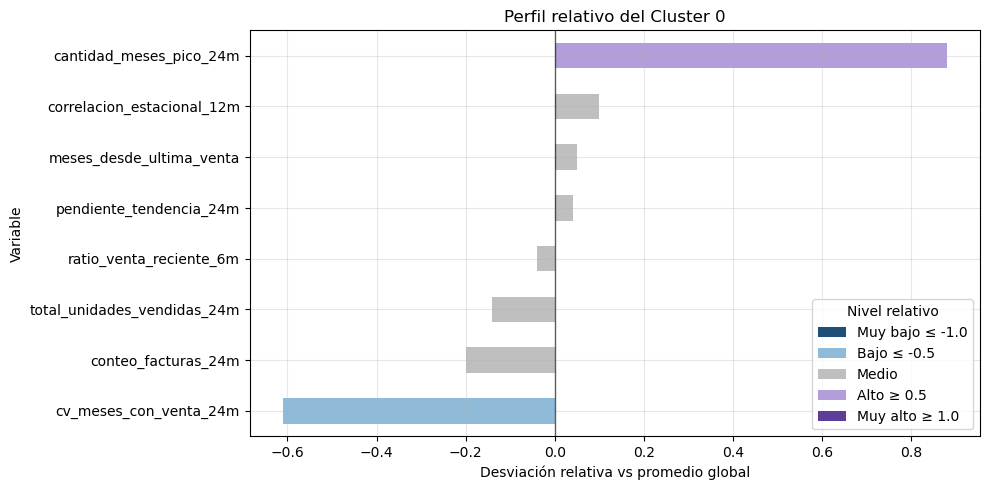

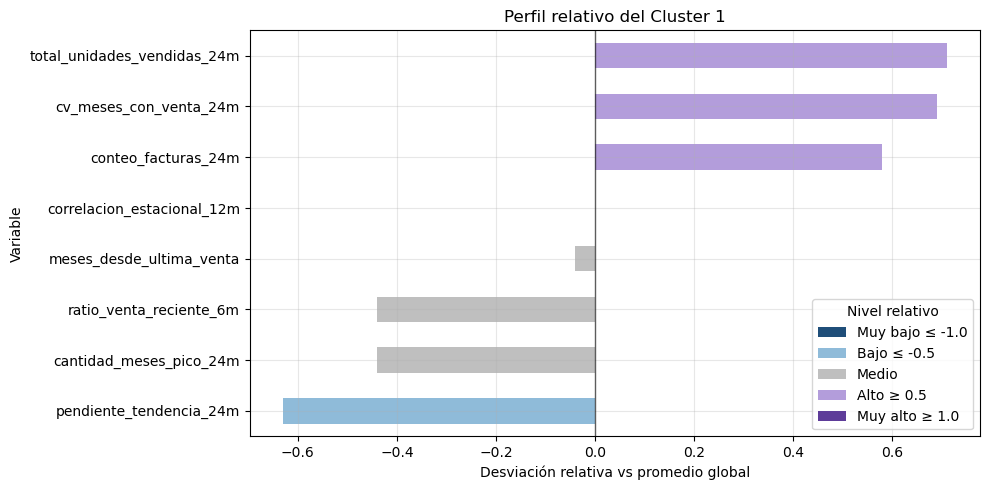

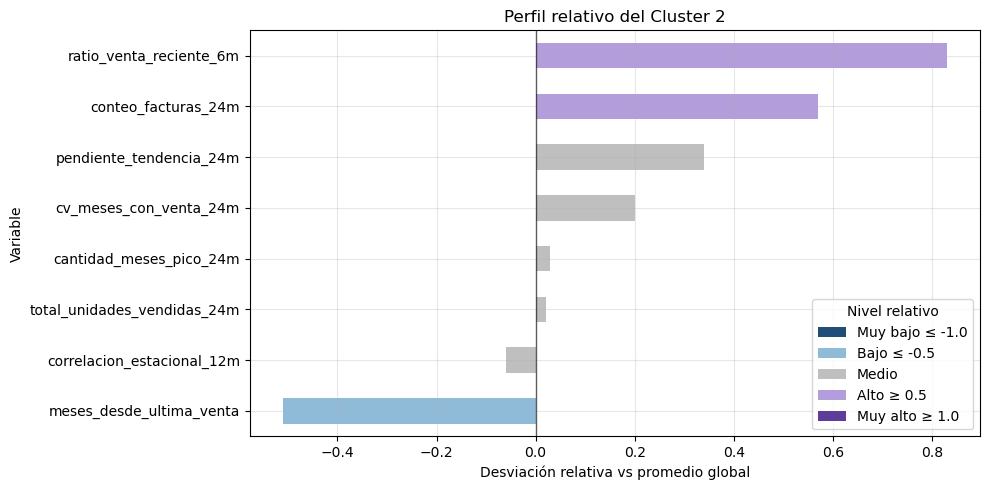

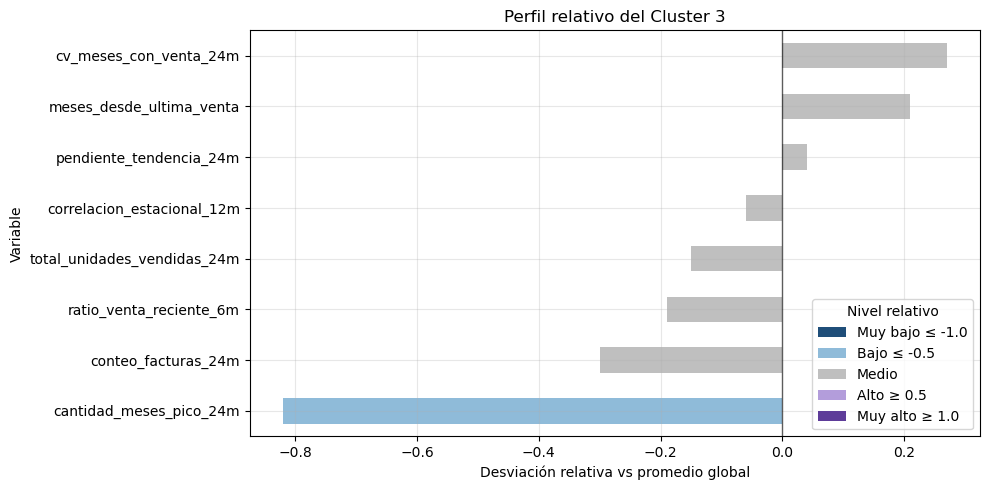

In [134]:
# ============================================================
# 9. Visualización del perfil relativo por cluster
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# for cluster in perfil_relativo_clusters.index:
#     plt.figure(figsize=(10, 5))

#     perfil_relativo_clusters.loc[cluster].plot(kind="barh")

#     plt.title(f"Perfil relativo del Cluster {cluster}")
#     plt.xlabel("Desviación relativa vs promedio global")
#     plt.ylabel("Variable")
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

# ------------------------------------------------------------
# Paleta orientada a magnitud, no a bueno/malo
# ------------------------------------------------------------
# Azul: valores por debajo del promedio global
# Gris: valores cercanos al promedio global
# Morado: valores por encima del promedio global
# ------------------------------------------------------------

colores_nivel = {
    "Muy bajo": "#1F4E79",  # azul profundo
    "Bajo": "#8FBBD9",      # azul suave
    "Medio": "#BFBFBF",     # gris neutro
    "Alto": "#B39DDB",      # morado suave
    "Muy alto": "#5E3C99"   # morado profundo
}


# ------------------------------------------------------------
# Visualización por cluster
# ------------------------------------------------------------

for cluster in perfil_relativo_clusters.index:
    
    serie_cluster = perfil_relativo_clusters.loc[cluster].sort_values()
    
    niveles = serie_cluster.apply(clasificar_nivel)
    colores = niveles.map(colores_nivel)

    plt.figure(figsize=(10, 5))

    serie_cluster.plot(
        kind="barh",
        color=colores
    )

    plt.axvline(
        x=0,
        color="black",
        linewidth=1,
        alpha=0.6
    )

    plt.title(f"Perfil relativo del Cluster {cluster}")
    plt.xlabel("Desviación relativa vs promedio global")
    plt.ylabel("Variable")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Leyenda
    leyenda = [
        Patch(facecolor=colores_nivel["Muy bajo"], label="Muy bajo ≤ -1.0"),
        Patch(facecolor=colores_nivel["Bajo"], label="Bajo ≤ -0.5"),
        Patch(facecolor=colores_nivel["Medio"], label="Medio"),
        Patch(facecolor=colores_nivel["Alto"], label="Alto ≥ 0.5"),
        Patch(facecolor=colores_nivel["Muy alto"], label="Muy alto ≥ 1.0")
    ]

    plt.legend(
        handles=leyenda,
        title="Nivel relativo",
        loc="lower right"
    )

    plt.show()


In [135]:
a=np.array([[2,3], [5,4]])
pd_a=pd.DataFrame(a)
pd_a.iloc[1]

0    5
1    4
Name: 1, dtype: int64

In [136]:
modelo_kmeans_final.cluster_centers_

array([[-0.07089773,  0.0038828 ,  0.08359096,  1.20481928,  0.1031667 ,
        -0.14518431,  0.2353635 , -0.39695002],
       [ 0.81954532,  0.51067739, -0.23501612, -0.6147541 , -0.01554818,
        -2.20872815,  0.17955012,  0.75711505],
       [ 0.83219354,  0.57118007,  0.76267693,  0.02702703, -0.2372257 ,
         2.24590849,  0.12681667,  0.35541221],
       [-0.19657042, -0.11669771, -0.0466639 , -1.13087248,  0.2008511 ,
         0.02356251,  0.11466106,  0.40793409]])

In [137]:
# ============================================================
# 10. Centroides del modelo K-Means
# ============================================================
# Los centroides muestran el centro de cada cluster en el espacio escalado.
# ============================================================

centroides=pd.DataFrame(modelo_kmeans_final.cluster_centers_, columns=X_scaled.columns).round(2)

centroides


,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
0,-0.07,0.00,0.08,1.20,0.10,-0.15,0.24,-0.40
1,0.82,0.51,-0.24,-0.61,-0.02,-2.21,0.18,0.76
2,0.83,0.57,0.76,0.03,-0.24,2.25,0.13,0.36
3,-0.20,-0.12,-0.05,-1.13,0.20,0.02,0.11,0.41


In [138]:
# ============================================================
# 11. Variables dominantes por centroide
# ============================================================

variables_dominantes_centorides=[]

for cluster in centroides.index:
    serie_centroide=centroides.loc[cluster]

    top_variables=(
        serie_centroide
        .abs()
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )

    for variable in top_variables:
        variables_dominantes_centorides.append(
    {"cluster":cluster, 
     "variable":variable,
     "valor_centroide":serie_centroide[variable]
     }
    )
df_variable_dominantes_centroides=pd.DataFrame(variables_dominantes_centorides)
df_variable_dominantes_centroides

,cluster,variable,valor_centroide
0,0,cantidad_meses_pico_24m,1.20
1,0,cv_meses_con_venta_24m,-0.40
2,0,correlacion_estacional_12m,0.24
3,0,pendiente_tendencia_24m,-0.15
4,0,meses_desde_ultima_venta,0.10
5,1,pendiente_tendencia_24m,-2.21
6,1,total_unidades_vendidas_24m,0.82
7,1,cv_meses_con_venta_24m,0.76
8,1,cantidad_meses_pico_24m,-0.61
9,1,conteo_facturas_24m,0.51


In [139]:
X_scaled

,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
0,1.091483,1.445606,0.116612,0.5,-0.500000,2.535510,-1.395539,-0.647172
1,1.091483,1.445606,0.281604,0.5,0.000000,-2.464490,-0.460134,0.987815
2,1.091483,1.303304,-0.354006,-1.5,0.000000,-2.464490,-0.338423,1.969279
3,0.849319,0.377015,0.818777,2.5,-0.500000,2.535510,-0.129915,-0.606646
4,1.091483,1.279714,0.643112,-0.5,-0.500000,2.535510,-0.496427,-0.094775
...,...,...,...,...,...,...,...,...
445,-0.506088,0.000000,0.991566,-1.5,0.292481,0.387171,0.073665,0.474045
446,-0.596233,-0.077306,-0.318418,-0.5,0.000000,-0.169530,0.276985,-0.307851
447,0.593254,-0.250031,0.612141,0.5,0.500000,1.024055,-0.244147,-0.055317
448,-0.548652,-0.250031,0.905307,-1.5,0.000000,0.290951,0.974527,0.114533


In [140]:
# ============================================================
# 12. Visualización PCA de clusters
# ============================================================
# PCA reduce las variables a dos dimensiones para visualizar
# la separación general de los clusters.
# ============================================================

#importamos libreria 
from sklearn.decomposition import PCA

pca =PCA(n_components=3, random_state=42)

X_pca = pca.fit_transform(X_scaled)

df_cluster["pca_1"] = X_pca[:, 0]
df_cluster["pca_2"] = X_pca[:, 1]
df_cluster["pca_3"] = X_pca[:, 2]

print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("Varianza explicada total:")
print(pca.explained_variance_ratio_.sum().round(4))

Varianza explicada por cada componente:
[0.3448666  0.3004253  0.11902566]
Varianza explicada total:
0.7643


In [141]:
# ============================================================
# Resumen de varianza explicada por PCA
# ============================================================

varianza_pca = pd.DataFrame({
    "componente": ["PCA 1", "PCA 2", "PCA 3"],
    "varianza_explicada": pca.explained_variance_ratio_,
    "varianza_acumulada": pca.explained_variance_ratio_.cumsum()
})

varianza_pca.round(4)

,componente,varianza_explicada,varianza_acumulada
0,PCA 1,0.3449,0.3449
1,PCA 2,0.3004,0.6453
2,PCA 3,0.1190,0.7643


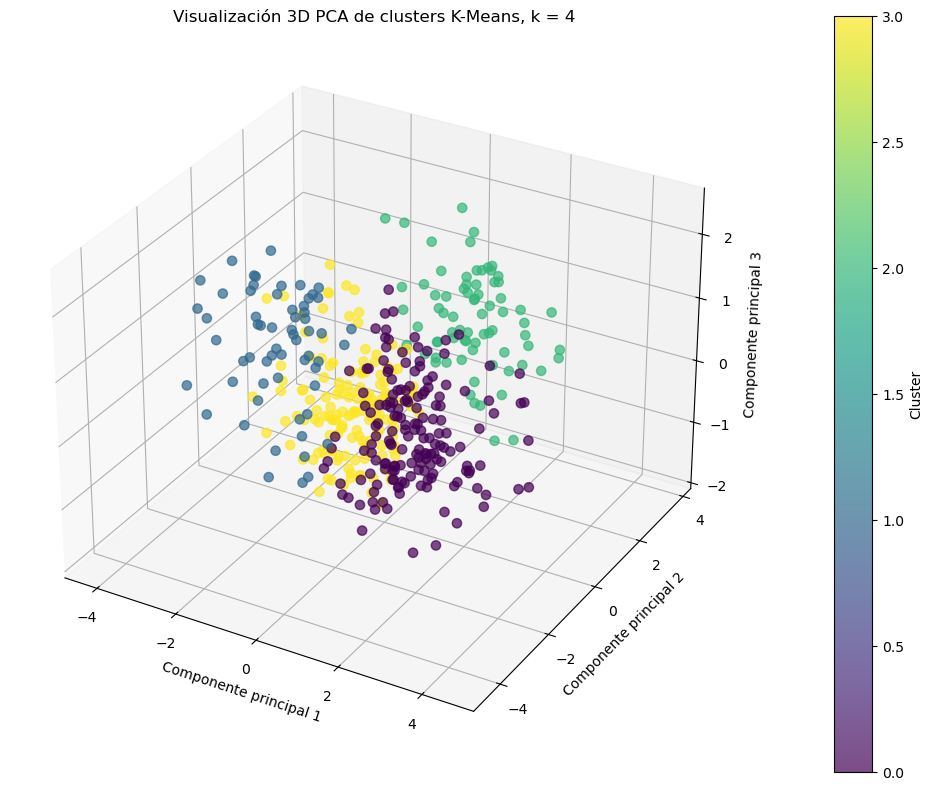

In [142]:
# ============================================================
# Visualización 3D de clusters usando PCA con colorbar
# ============================================================

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df_cluster["pca_1"],
    df_cluster["pca_2"],
    df_cluster["pca_3"],
    c=df_cluster["cluster_kmeans_final"],
    alpha=0.7,
    s=45
)

ax.set_title("Visualización 3D PCA de clusters K-Means, k = 4")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.set_zlabel("Componente principal 3")

colorbar = plt.colorbar(scatter, ax=ax, pad=0.1)
colorbar.set_label("Cluster")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [143]:
# ============================================================
# Asignación interpretativa de clusters y modelos candidatos
# ============================================================
# Esta asignación no representa el modelo ganador.
# Su objetivo es conectar el perfil matemático de cada cluster
# con las familias de algoritmos que serán evaluadas en la etapa
# posterior de forecast.
# ============================================================

descripcion_clusters = {
    0: "Demanda con picos frecuentes y variabilidad controlada",
    1: "Demanda históricamente relevante, variable y con posible desaceleración",
    2: "Demanda activa y reciente con señales de crecimiento",
    3: "Demanda baja, intermitente o menos dinámica"
}

modelos_candidatos_cluster = {
    0: [
        "Moving Average",
        "Exponential Smoothing",
        "Random Forest Regressor",
        "XGBoost/LightGBM"
    ],
    1: [
        "ETS con tendencia amortiguada",
        "ARIMA/AutoARIMA",
        "Random Forest Regressor",
        "XGBoost/LightGBM"
    ],
    2: [
        "Exponential Smoothing",
        "ARIMA/AutoARIMA",
        "Random Forest Regressor",
        "XGBoost/LightGBM"
    ],
    3: [
        "Naive Forecast",
        "Moving Average",
        "Croston",
        "SBA",
        "TSB"
    ]
}

In [144]:
# ============================================================
# Agregar interpretación y modelos candidatos al dataframe

df_cluster["descripcion_cluster"]=df_cluster["cluster_kmeans_final"].map(descripcion_clusters)

df_cluster["modelos_candidatos_forecast"]=df_cluster["cluster_kmeans_final"].map(modelos_candidatos_cluster)

df_cluster["modelos_candidatos_forecast"] = (df_cluster["modelos_candidatos_forecast"].apply(lambda modelos: ", ".join(modelos)))

df_cluster[
    [
        "codigo_articulo",
        "descripcion_completa",
        "cluster_kmeans_final",
        "descripcion_cluster",
        "modelos_candidatos_forecast"
    ]
].head()

,codigo_articulo,descripcion_completa,cluster_kmeans_final,descripcion_cluster,modelos_candidatos_forecast
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,2,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."
1,W8,"Cinta para husos, Habasit, W-8",1,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
2,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",1,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
3,C3.5-TEH-14.984,RODILLO RETRO PSV/1.20F14.89N.38,2,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."
4,RB330-3PLY-24''-SHRD,"Banda de Hule y lona de 24"" 3 lonas",2,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."


In [145]:
# ============================================================
# Tabla resumen de clusters y modelos candidatos
# ============================================================

resumen_modelos_por_cluster=(df_cluster
                             .groupby(["cluster_kmeans_final", "descripcion_cluster", "modelos_candidatos_forecast"])
                             .size()
                             .reset_index(name="cantidad_articulos")
                             )

resumen_modelos_por_cluster["porcentaje"] = (
    resumen_modelos_por_cluster["cantidad_articulos"]/resumen_modelos_por_cluster["cantidad_articulos"].sum()*100
).round(2)

resumen_modelos_por_cluster

,cluster_kmeans_final,descripcion_cluster,modelos_candidatos_forecast,cantidad_articulos,porcentaje
0,0,Demanda con picos frecuentes y variabilidad co...,"Moving Average, Exponential Smoothing, Random ...",166,36.89
1,1,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA...",61,13.56
2,2,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random...",74,16.44
3,3,"Demanda baja, intermitente o menos dinámica","Naive Forecast, Moving Average, Croston, SBA, TSB",149,33.11


In [146]:
# ============================================================
# Exportar dataset clusterizado con modelos candidatos
# ============================================================

ruta_salida = "./Datos/df_articulos_forecast_clusterizado_modelos_candidatos.xlsx"

df_cluster.to_excel(
    ruta_salida,
    index=False
)

print(f"Archivo exportado correctamente: {ruta_salida}")

Archivo exportado correctamente: ./Datos/df_articulos_forecast_clusterizado_modelos_candidatos.xlsx


In [147]:


# ============================================================
# Cargar CSV histórico aplicable a forecast
# ============================================================

import pandas as pd
import numpy as np

ruta_csv_base = "./Datos/dataframe_aplica_forecast_true_rev_2026-07-18.xlsx"

df_historial_forecast = pd.read_excel(
    ruta_csv_base,
)

print("Dimensiones del CSV histórico:")
print(df_historial_forecast.shape)

df_historial_forecast.head()

Dimensiones del CSV histórico:
(450, 125)


,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,unidad_medida_inventario,marca_fabricante,ultima_fecha_compra,ultimo_precio_compra,...,valor_venta_mensual_24m,deficit_punto_reorden,deficit_punto_reorden_positivo,monto_riesgo_inmediato,monto_riesgo_proximo,score_prioridad_articulo,venta_mensual_en_revision,venta_promedio_reciente_last_6m,ratio_venta_reciente_6m,motivo_aplica_forecast
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,CENTROS DE CARGA E INTERRUPTORES,NaN,UNI,SIEMENS,2026-06-26,32.680000,...,20634.356250,-8.217442e+02,0.000000,0.000000,46283.713583,46283.713583,20634.356250,395.500000,0.845612,Aplica forecast
1,W8,"Cinta para husos, Habasit, W-8",FAJAS,BANDAS,CORREAS PLANAS DE TRANSMISION,CORREAS PLANAS DE TRANSMISION,CM2,HABASIT ROCUA,2026-01-31,0.007366,...,2476.004819,-1.687231e+06,0.000000,0.000000,0.000000,0.000000,0.000000,240040.970000,0.964050,Aplica forecast
2,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",FAJAS,CORREAS,REDONDAS,REDONDAS,MT,SHARDA,2026-02-27,19.335359,...,2238.766294,-2.134083e+02,0.000000,0.000000,3384.525384,3384.525384,0.000000,43.551667,0.507788,Aplica forecast
3,C3.5-TEH-14.984,RODILLO RETRO PSV/1.20F14.89N.38,POLEAS RODI.Y TAMB.,NaN,NaN,NaN,UNI,PRECISION INC,2026-05-31,51.088667,...,1643.777861,-1.556889e+02,0.000000,0.000000,0.000000,0.000000,0.000000,32.166667,1.349650,Aplica forecast
4,RB330-3PLY-24''-SHRD,"Banda de Hule y lona de 24"" 3 lonas",FAJAS,CORREAS,REDONDAS,REDONDAS,MT,SHARDA,2026-06-01,21.100484,...,1654.161893,2.472802e+02,247.280222,7043.938685,0.000000,7043.938685,1654.161893,71.051667,1.223552,Aplica forecast


In [148]:
# ============================================================
# Validar columnas necesarias en df_cluster a trasladar
# ============================================================

columnas_cluster_necesarias = [
    "codigo_articulo",
    "cluster_kmeans_final",
    "descripcion_cluster",
    "modelos_candidatos_forecast"
]

faltantes = [
    col for col in columnas_cluster_necesarias
    if col not in df_cluster.columns
]

if faltantes:
    raise ValueError(f"Faltan columnas en df_cluster: {faltantes}")

df_cluster_join = df_cluster[columnas_cluster_necesarias].copy()

df_cluster_join.head()

,codigo_articulo,cluster_kmeans_final,descripcion_cluster,modelos_candidatos_forecast
0,US2: QF120A,2,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."
1,W8,1,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
2,RB330-3PLY-30''-SHRD,1,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
3,C3.5-TEH-14.984,2,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."
4,RB330-3PLY-24''-SHRD,2,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."


In [149]:
# ============================================================
# 4. Validar primary key
# ============================================================

if "codigo_articulo" not in df_historial_forecast.columns:
    raise ValueError("El CSV histórico no contiene la columna 'codigo_articulo'.")

if "codigo_articulo" not in df_cluster_join.columns:
    raise ValueError("La tabla de clusters no contiene la columna 'codigo_articulo'.")

print("✅ Llave codigo_articulo disponible en ambos DataFrames.")

✅ Llave codigo_articulo disponible en ambos DataFrames.


In [150]:
# ============================================================
# 5. Normalizar codigo_articulo antes del join
# ============================================================

df_historial_forecast["codigo_articulo"] = (
    df_historial_forecast["codigo_articulo"]
    .astype(str)
    .str.strip()
)

df_cluster_join["codigo_articulo"] = (
    df_cluster_join["codigo_articulo"]
    .astype(str)
    .str.strip()
)

In [151]:
# ============================================================
# 6. Unir historial con información de clusterización
# ============================================================

df_historial_clusterizado = df_historial_forecast.merge(
    df_cluster_join,
    on="codigo_articulo",
    how="left",
    validate="many_to_one"
)

print("Dimensiones antes del join:")
print(df_historial_forecast.shape)

print("Dimensiones después del join:")
print(df_historial_clusterizado.shape)

df_historial_clusterizado.head()

Dimensiones antes del join:
(450, 125)
Dimensiones después del join:
(450, 128)


,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,unidad_medida_inventario,marca_fabricante,ultima_fecha_compra,ultimo_precio_compra,...,monto_riesgo_inmediato,monto_riesgo_proximo,score_prioridad_articulo,venta_mensual_en_revision,venta_promedio_reciente_last_6m,ratio_venta_reciente_6m,motivo_aplica_forecast,cluster_kmeans_final,descripcion_cluster,modelos_candidatos_forecast
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,CENTROS DE CARGA E INTERRUPTORES,NaN,UNI,SIEMENS,2026-06-26,32.680000,...,0.000000,46283.713583,46283.713583,20634.356250,395.500000,0.845612,Aplica forecast,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."
1,W8,"Cinta para husos, Habasit, W-8",FAJAS,BANDAS,CORREAS PLANAS DE TRANSMISION,CORREAS PLANAS DE TRANSMISION,CM2,HABASIT ROCUA,2026-01-31,0.007366,...,0.000000,0.000000,0.000000,0.000000,240040.970000,0.964050,Aplica forecast,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
2,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",FAJAS,CORREAS,REDONDAS,REDONDAS,MT,SHARDA,2026-02-27,19.335359,...,0.000000,3384.525384,3384.525384,0.000000,43.551667,0.507788,Aplica forecast,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
3,C3.5-TEH-14.984,RODILLO RETRO PSV/1.20F14.89N.38,POLEAS RODI.Y TAMB.,NaN,NaN,NaN,UNI,PRECISION INC,2026-05-31,51.088667,...,0.000000,0.000000,0.000000,0.000000,32.166667,1.349650,Aplica forecast,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."
4,RB330-3PLY-24''-SHRD,"Banda de Hule y lona de 24"" 3 lonas",FAJAS,CORREAS,REDONDAS,REDONDAS,MT,SHARDA,2026-06-01,21.100484,...,7043.938685,0.000000,7043.938685,1654.161893,71.051667,1.223552,Aplica forecast,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."


In [152]:
# ============================================================
# 7. Validar registros sin cluster asignado
# ============================================================

sin_cluster = df_historial_clusterizado["cluster_kmeans_final"].isna().sum()

print(f"Registros sin cluster asignado: {sin_cluster}")

if sin_cluster > 0:
    articulos_sin_cluster = (df_historial_clusterizado[df_historial_clusterizado["cluster_kmeans_final"].isna()]["codigo_articulo"])

    print(f"Artículos únicos sin cluster: {articulos_sin_cluster.shape[0]}")
    display(articulos_sin_cluster.head(30))

Registros sin cluster asignado: 2
Artículos únicos sin cluster: 2


208    2024-07-01 00:00:00
280    2014-07-01 00:00:00
Name: codigo_articulo, dtype: str

In [153]:
# ============================================================
# 8. Imputar columnas de revisión metodológica
# ============================================================

fecha_revision_cluster = "2026-08-14"
revisado_por = "Christian Hoppe"

# Si las columnas no existen, se crean
columnas_revision = [
    "modelo_forecast",
    "tipo_demanda",
    "comentario_rev",
    "fecha_revision",
    "revisado_por"
]

for col in columnas_revision:
    if col not in df_historial_clusterizado.columns:
        df_historial_clusterizado[col] = np.nan

# modelo_forecast:
# Todavía no es el modelo ganador.
# Se colocan modelos candidatos sugeridos por cluster.
df_historial_clusterizado["modelo_forecast"] = (
    df_historial_clusterizado["modelos_candidatos_forecast"]
)

# tipo_demanda:
# Se usa la descripción interpretativa del cluster.
df_historial_clusterizado["tipo_demanda"] = (
    df_historial_clusterizado["descripcion_cluster"]
)

# comentario metodológico
df_historial_clusterizado["comentario_rev"] = (
    "Asignación preliminar basada en clusterización K-Means k=4; "
    "los modelos indicados son candidatos a evaluar, no modelo ganador definitivo."
)

df_historial_clusterizado["fecha_revision"] = fecha_revision_cluster
df_historial_clusterizado["revisado_por"] = revisado_por

In [157]:
# ============================================================
# 11. Exportar CSV final enriquecido para capítulo de modelado
# ============================================================

ruta_salida = "./Datos/dataframe_aplica_forecast_true_clusterizado_modelos_2026_07_18.xlsx"

df_historial_clusterizado.to_excel(
    ruta_salida,
    index=False,
)

print(f"aRCHIVO exportado correctamente: {ruta_salida}")

aRCHIVO exportado correctamente: ./Datos/dataframe_aplica_forecast_true_clusterizado_modelos_2026_07_18.xlsx
